In [5]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.transforms as T
from torchmetrics.classification import MulticlassRecall, MulticlassAccuracy, MulticlassConfusionMatrix

from tqdm import tqdm
from collections import Counter

from Data_Utility.lookup_size import lookup_size_from_excel
from Data_Utility.dataset import PollenFolderWithSizeDataset
from Data_Utility.binary_subset import BinaryPairDataset

from models.basemodel import CNNWithSizeMLP
from models.basemodel_256 import CNN256WithSizeMLP
#from models.CNN_MLPlayers import CNNWithSizeMLPlayers
from models.convnext_model import ConvNeXtTinyWithSize
from models.specialist_binary import BinarySpecialist

from engine.train_epoch import train_epoch
from engine.train_model import train_model
from engine.eval_epoch import eval_epoch
from engine.plots_loss_accuracy import plot_training_history
from engine.plot_confmat import plot_confusion_matrix
from engine.data_setup import setup_datasets

from engine.specialist_pair import choose_specialist_pair
from engine.train_specialist import train_binary_specialist
from engine.two_stage_infer import two_stage_predict

from loss_fn.focal_loss import FocalLoss
print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)


Using device: cuda


In [3]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=False
    ,val_bool=False
    ,aug_bool=False
    ,norm_bool=False
    ,sep_val_bool=False
)
num_classes = len(classes)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 7922 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: False
Total scanned images: 8078
   Final dataset size:   7922
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 
Dropped missing:      156


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 7922
Dataset setup complete.


In [14]:
train_counts = Counter([train_dataset[i][2].item() for i in range(len(train_dataset))])
test_counts = Counter([test_dataset[i][2].item() for i in range(len(test_dataset))])
print("Training set class distribution:")
for k in sorted(train_counts):
    print(k, idx_to_class[int(k)], train_counts[k])

Training set class distribution:
0 Bellis perennis 856
1 Brassica napus 795
2 Capsella bursa-pastoris 817
3 Cichorium intybus 870
4 Crepis capillaris 799
5 Hieracium umbellatum 735
6 Hypochaeris radicata 717
7 Sonchus arvensis 666
8 Tragopogon pratensis 834
9 Tussilago farfara 833


In [4]:

print("\nTest set class distribution:")
for k in sorted(test_counts):
    print(k, idx_to_class[int(k)], test_counts[k])


Test set class distribution:
0 Bellis perennis 142
1 Brassica napus 200
2 Capsella bursa-pastoris 183
3 Cichorium intybus 130
4 Crepis capillaris 200
5 Hieracium umbellatum 200
6 Hypochaeris radicata 200
7 Sonchus arvensis 334
8 Tragopogon pratensis 166
9 Tussilago farfara 167


# Base Model (Erik's)

## Base Model (Erik's) & Excluding missing size

In [13]:
model_base = CNNWithSizeMLP(num_classes=num_classes).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_base.parameters(), lr=0.001)

In [13]:
BATCHSIZE = 32
EPOCHS = 20

history, test_loader = train_model(
    model=model_base
    ,train_dataset=train_dataset
    ,test_dataset=test_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="base_model.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=20
    ,early_stopping_patience=0
)

100%|██████████| 253/253 [00:25<00:00, 10.10it/s]


Epoch 1/20 | Train Loss: 0.0428, Train Acc: 0.9854


100%|██████████| 253/253 [00:23<00:00, 10.88it/s]


Epoch 2/20 | Train Loss: 0.0223, Train Acc: 0.9938


100%|██████████| 253/253 [00:23<00:00, 10.98it/s]


...

Epoch 18/20 | Train Loss: 0.0112, Train Acc: 0.9958


100%|██████████| 253/253 [00:22<00:00, 11.10it/s]


Epoch 19/20 | Train Loss: 0.0206, Train Acc: 0.9926


100%|██████████| 253/253 [00:22<00:00, 11.10it/s]


Epoch 20/20 | Train Loss: 0.0145, Train Acc: 0.9959



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 7.536622047424316
Mean of batch means: 0.8102777014013196
Mean of batch stds: 0.9024200390596859

Test Accuracy: 0.7680
Test Recall per class:
Class 0 (Bellis perennis): 0.3521
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9781
Class 3 (Cichorium intybus): 0.9846
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9450
Class 6 (Hypochaeris radicata): 0.5050
Class 7 (Sonchus arvensis): 0.9162
Class 8 (Tragopogon pratensis): 0.9458
Class 9 (Tussilago farfara): 0.9940


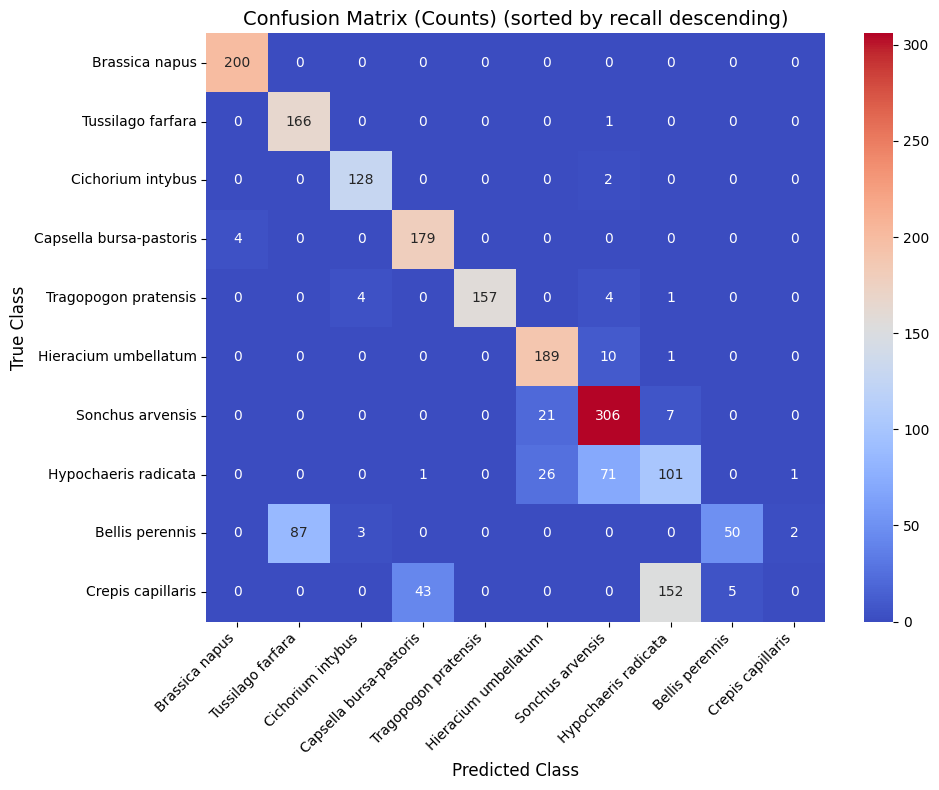

In [14]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/base_model.pth", map_location=device)
model_base.load_state_dict(ckpt["model_state_dict"])
model_base.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model_base, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

## Investigate worst recall species: 
Class 4 (Crepis capillaris): 0.0000 is being confused the most with:
- Class 6 (Hypochaeris radicata): 0.5050
- Class 2 (Capsella bursa-pastoris): 0.9781

Class 0 (Bellis perennis): 0.3521
- Class 9 (Tussilago farfara): 0.9940

Class 6 (Hypochaeris radicata): 0.5050
- Class 7 (Sonchus arvensis): 0.9162
- Class 5 (Hieracium umbellatum): 0.9450

In [9]:
import torch
import numpy as np

def extract_backbone_and_combined(model, loader, device, selected_classes=(4,6,2)):
    """
    Returns:
      X_backbone: [N, D] backbone features
      X_combined: [N, D+2] backbone features concatenated with size
      sizes_np:   [N, 2]  (major, minor)
      y_np:       [N]
    """
    model.eval()
    selected_classes = torch.tensor(selected_classes, device=device)

    feats_list, comb_list, sizes_list, y_list = [], [], [], []

    with torch.no_grad():
        for imgs, sizes, labels in loader:
            imgs = imgs.to(device)
            sizes = sizes.to(device)
            labels = labels.to(device)

            mask = torch.isin(labels, selected_classes)
            if mask.sum() == 0:
                continue

            imgs_m = imgs[mask]
            sizes_m = sizes[mask]
            labels_m = labels[mask]

            # backbone features
            f = model.backbone(imgs_m)                 # [b, D]
            x_comb = torch.cat([f, sizes_m], dim=1)    # [b, D+2]

            feats_list.append(f.cpu())
            comb_list.append(x_comb.cpu())
            sizes_list.append(sizes_m.cpu())
            y_list.append(labels_m.cpu())

    X_backbone = torch.cat(feats_list, dim=0).numpy()
    X_combined = torch.cat(comb_list, dim=0).numpy()
    sizes_np   = torch.cat(sizes_list, dim=0).numpy()
    y_np       = torch.cat(y_list, dim=0).numpy()

    return X_backbone, X_combined, sizes_np, y_np

In [24]:

def plot_2d_ax(X_2d, y, idx_to_class, title, ax):
    for cls in sorted(set(y)):
        mask = (y == cls)
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], alpha=0.7, label=idx_to_class[cls])
    ax.set_title(title)
    ax.legend(fontsize=8)

In [20]:
def plot_size_scatter_ax(S, y, idx_to_class, classes, ax):
    for cls in classes:
        mask = (y == cls)
        ax.scatter(S[mask, 0], S[mask, 1], alpha=0.6, label=idx_to_class[cls])
    ax.set_xlabel("Major axis")
    ax.set_ylabel("Minor axis")
    ax.set_title(f"Scatter: {classes}")
    ax.legend(fontsize=8)

def plot_size_histograms_ax(S, y, idx_to_class, classes, ax_major, ax_minor, bins=30):
    for cls in classes:
        mask = (y == cls)
        ax_major.hist(S[mask, 0], bins=bins, alpha=0.5, label=idx_to_class[cls])
        ax_minor.hist(S[mask, 1], bins=bins, alpha=0.5, label=idx_to_class[cls])

    ax_major.set_title(f"Major axis: {classes}")
    ax_major.set_xlabel("Major axis")
    ax_major.legend(fontsize=8)

    ax_minor.set_title(f"Minor axis: {classes}")
    ax_minor.set_xlabel("Minor axis")
    ax_minor.legend(fontsize=8)

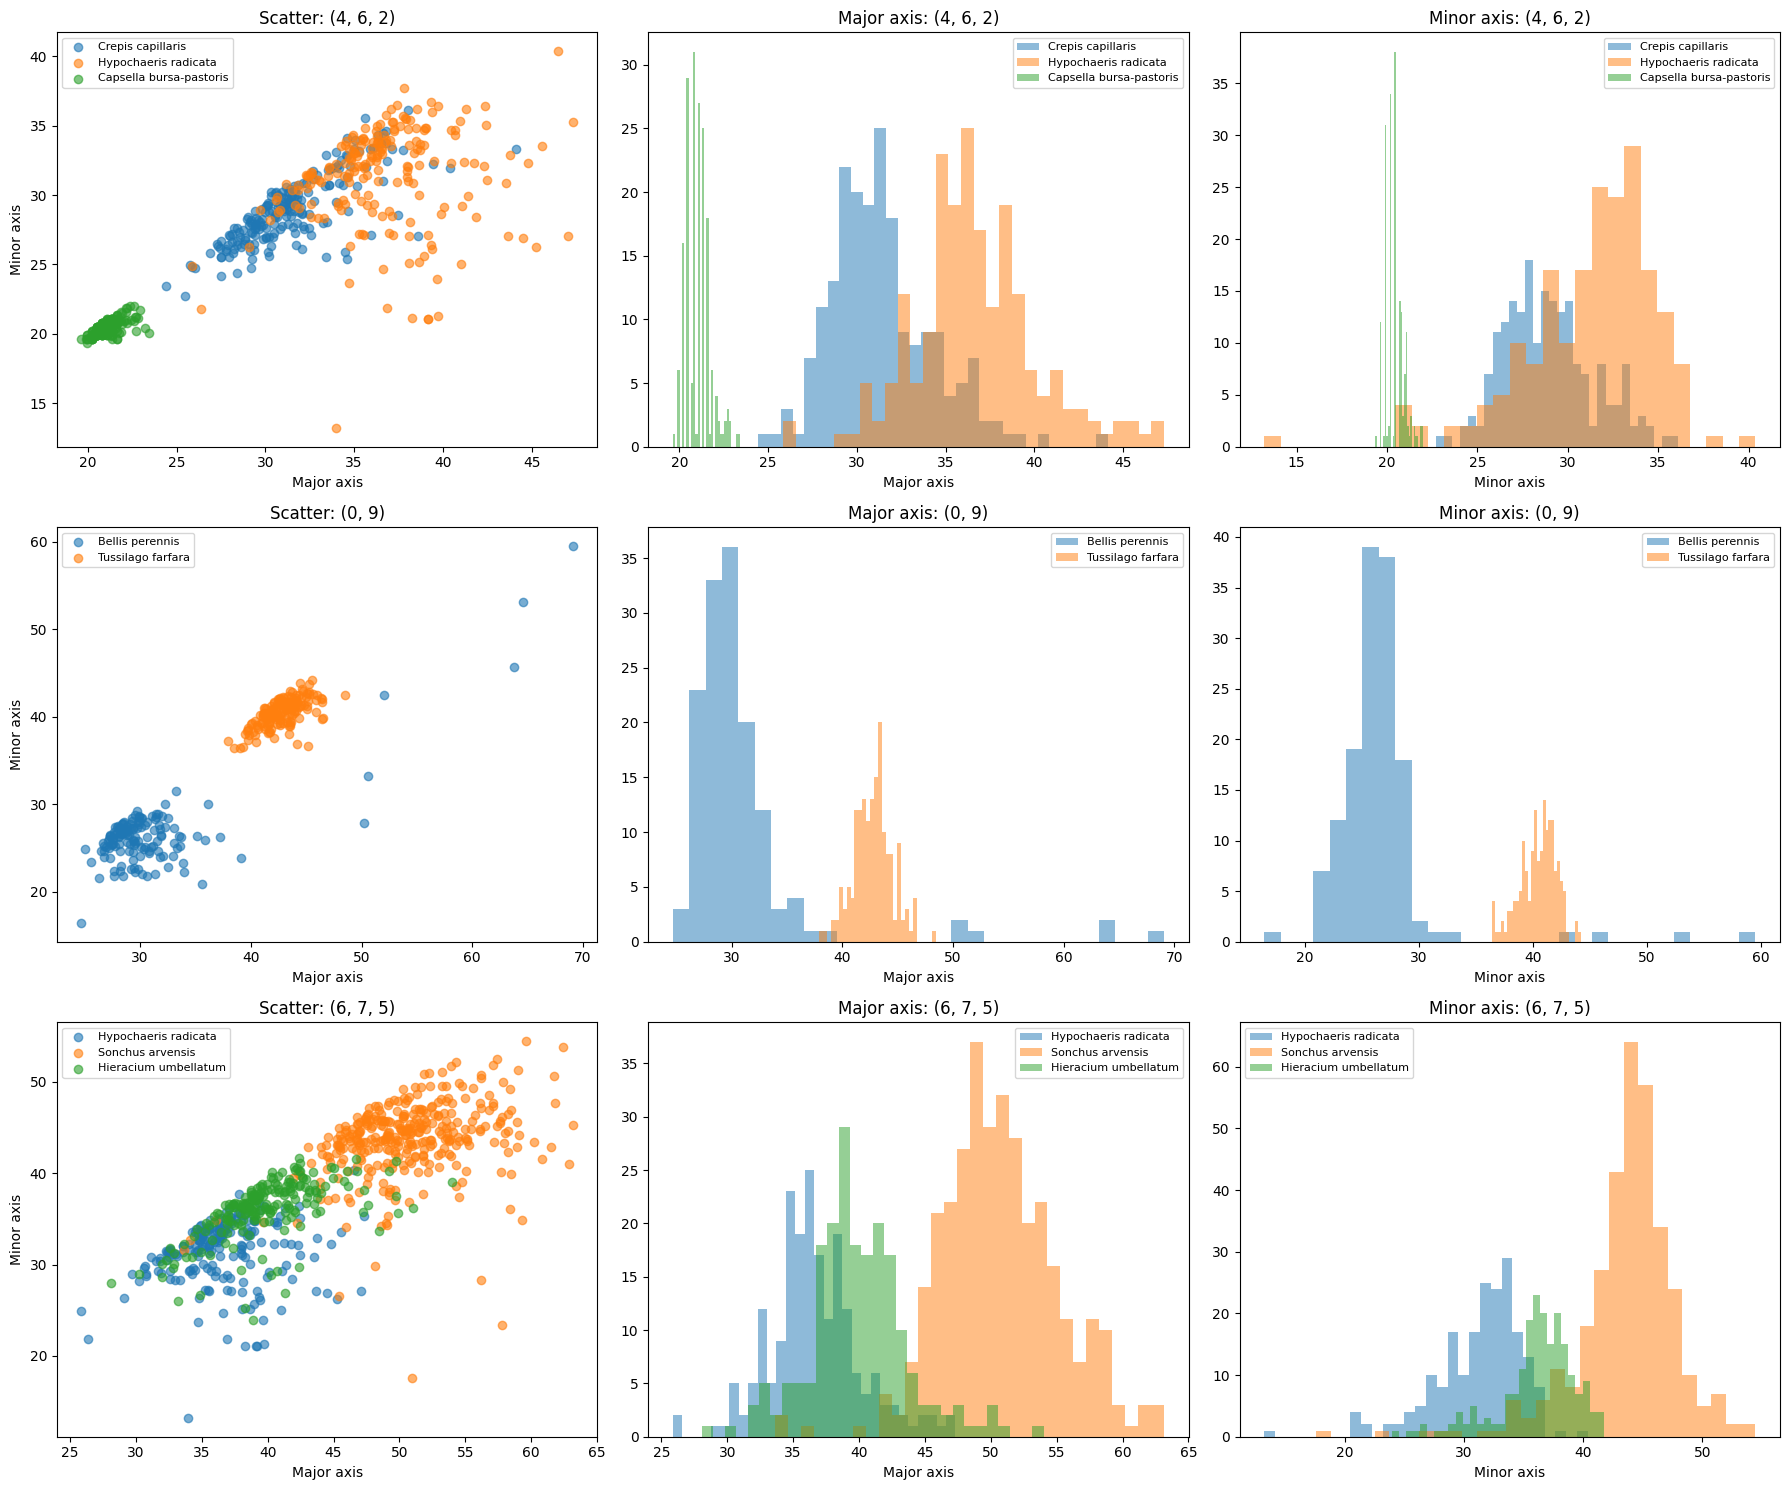

In [21]:
classes_chosen = [(4, 6, 2), (0, 9), (6, 7, 5)]

fig, ax = plt.subplots(
    nrows=len(classes_chosen),
    ncols=3,
    figsize=(18, 5 * len(classes_chosen))
)

# in case len(classes_chosen) == 1
if len(classes_chosen) == 1:
    ax = np.expand_dims(ax, axis=0)

for i, cls_tuple in enumerate(classes_chosen):
    Xb, Xc, S, y = extract_backbone_and_combined(
        model_base,
        test_loader,
        device,
        selected_classes=cls_tuple
    )

    plot_size_scatter_ax(S, y, idx_to_class, classes=cls_tuple, ax=ax[i, 0])
    plot_size_histograms_ax(S, y, idx_to_class, classes=cls_tuple,
                            ax_major=ax[i, 1], ax_minor=ax[i, 2])

plt.tight_layout()
plt.show()

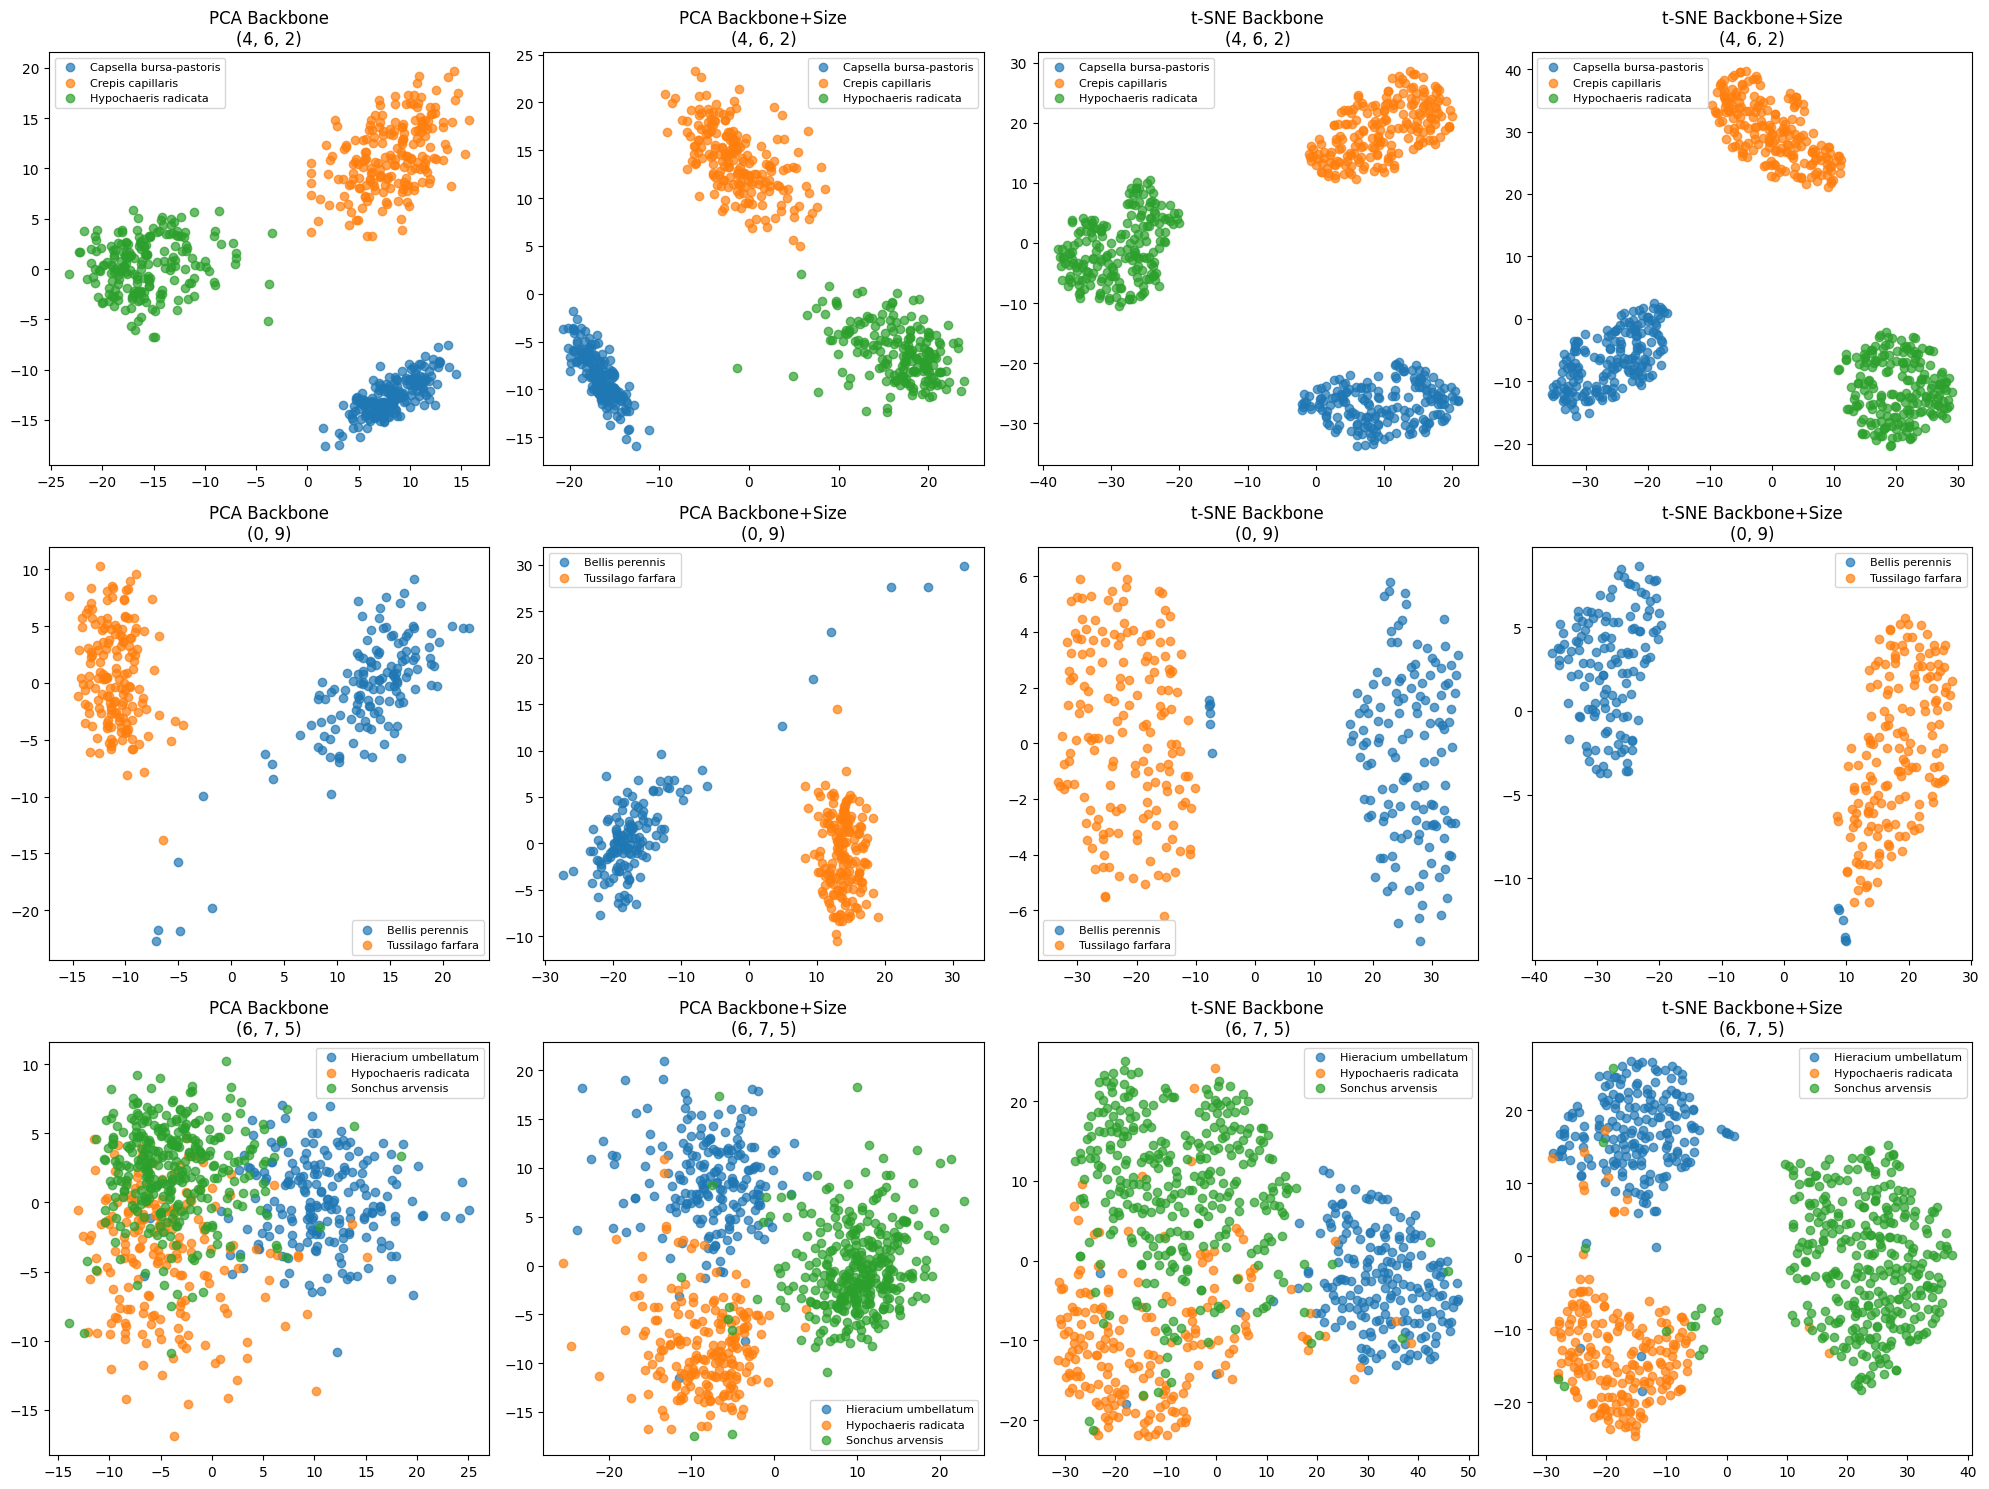

In [25]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

classes_chosen = [(4,6,2), (0,9), (6,7,5)]

fig, ax = plt.subplots(len(classes_chosen), 4, figsize=(20, 5 * len(classes_chosen)))

if len(classes_chosen) == 1:
    ax = np.expand_dims(ax, axis=0)

for i, cls_tuple in enumerate(classes_chosen):
    Xb, Xc, S, y = extract_backbone_and_combined(
        model_base,
        test_loader,
        device,
        selected_classes=cls_tuple
    )

    # PCA
    pca_b = PCA(n_components=2).fit_transform(Xb)
    pca_c = PCA(n_components=2).fit_transform(Xc)

    # t-SNE
    subset = min(1500, len(y))
    Xb_sub, Xc_sub, y_sub = Xb[:subset], Xc[:subset], y[:subset]

    tsne_b = TSNE(n_components=2, perplexity=30, random_state=42, init="pca").fit_transform(Xb_sub)
    tsne_c = TSNE(n_components=2, perplexity=30, random_state=42, init="pca").fit_transform(Xc_sub)

    plot_2d_ax(pca_b, y, idx_to_class, f"PCA Backbone\n{cls_tuple}", ax[i, 0])
    plot_2d_ax(pca_c, y, idx_to_class, f"PCA Backbone+Size\n{cls_tuple}", ax[i, 1])
    plot_2d_ax(tsne_b, y_sub, idx_to_class, f"t-SNE Backbone\n{cls_tuple}", ax[i, 2])
    plot_2d_ax(tsne_c, y_sub, idx_to_class, f"t-SNE Backbone+Size\n{cls_tuple}", ax[i, 3])

plt.tight_layout()
plt.show()

## Base Model (Erik's) & Filling missing size & Validation split

In [ ]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=False
    ,aug_bool=False
    ,norm_bool=False
    ,sep_val_bool=False
)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 8078
Dataset setup complete.


In [ ]:
train_counts = Counter([train_dataset[i][2].item() for i in range(len(train_dataset))])
test_counts = Counter([test_dataset[i][2].item() for i in range(len(test_dataset))])
print("Training set class distribution:")
for k in sorted(train_counts):
    print(k, idx_to_class[int(k)], train_counts[k])

Training set class distribution:
0 Bellis perennis 858
1 Brassica napus 800
2 Capsella bursa-pastoris 817
3 Cichorium intybus 870
4 Crepis capillaris 800
5 Hieracium umbellatum 800
6 Hypochaeris radicata 800
7 Sonchus arvensis 666
8 Tragopogon pratensis 834
9 Tussilago farfara 833


In [8]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=True
    ,aug_bool=False
    ,norm_bool=False
    ,sep_val_bool=False
)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 6462
Validation subset size: 1616
Train subset size: 6462
Validation subset size: 1616
Datase

In [ ]:
train_counts = Counter([train_dataset[i][2].item() for i in range(len(train_dataset))])

print("Training set class distribution:")
for k in sorted(train_counts):
    print(k, idx_to_class[int(k)], train_counts[k])

Training set class distribution:
0 Bellis perennis 677
1 Brassica napus 629
2 Capsella bursa-pastoris 664
3 Cichorium intybus 690
4 Crepis capillaris 647
5 Hieracium umbellatum 640
6 Hypochaeris radicata 662
7 Sonchus arvensis 526
8 Tragopogon pratensis 666
9 Tussilago farfara 661


In [27]:
val_counts = Counter([val_dataset[i][2].item() for i in range(len(val_dataset))])

print("Validation set class distribution:")
for k in sorted(val_counts):
    print(k, idx_to_class[int(k)], val_counts[k])

Validation set class distribution:
0 Bellis perennis 181
1 Brassica napus 171
2 Capsella bursa-pastoris 153
3 Cichorium intybus 180
4 Crepis capillaris 153
5 Hieracium umbellatum 160
6 Hypochaeris radicata 138
7 Sonchus arvensis 140
8 Tragopogon pratensis 168
9 Tussilago farfara 172


In [9]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model_base
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="base_model_fill_val.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=20
    ,early_stopping_patience=8
)

100%|██████████| 202/202 [00:18<00:00, 10.94it/s]


Epoch 1/20 | Train Loss: 0.1518, Train Acc: 0.9536
| Val Loss: 0.1872, Val Acc: 0.9375
Val Recall per class: tensor([1.0000, 0.7018, 1.0000, 0.9833, 1.0000, 0.8813, 0.9710, 0.8357, 0.9940,
        1.0000])
Saved new best model (Val Acc = 0.9375)


100%|██████████| 202/202 [00:18<00:00, 10.95it/s]


Epoch 2/20 | Train Loss: 0.0915, Train Acc: 0.9680
| Val Loss: 0.3567, Val Acc: 0.9028


100%|██████████| 202/202 [00:18<00:00, 11.01it/s]


...

Epoch 18/20 | Train Loss: 0.0307, Train Acc: 0.9896
| Val Loss: 0.2280, Val Acc: 0.9381


100%|██████████| 202/202 [00:18<00:00, 10.98it/s]


Epoch 19/20 | Train Loss: 0.0353, Train Acc: 0.9892
| Val Loss: 0.1850, Val Acc: 0.9542


100%|██████████| 202/202 [00:18<00:00, 10.95it/s]


Epoch 20/20 | Train Loss: 0.0180, Train Acc: 0.9938
| Val Loss: 0.1204, Val Acc: 0.9660
Val Recall per class: tensor([0.9834, 0.9883, 0.9935, 0.9222, 0.9935, 0.9875, 0.9710, 0.9714, 0.8571,
        1.0000])
Reloaded best model from epoch 15 (Val Acc=0.9858)



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 9.177812576293945
Mean of batch means: 0.8234773805884065
Mean of batch stds: 0.9290560894325132

Test Accuracy: 0.7986
Test Recall per class:
Class 0 (Bellis perennis): 0.8099
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0150
Class 5 (Hieracium umbellatum): 0.8900
Class 6 (Hypochaeris radicata): 0.6250
Class 7 (Sonchus arvensis): 0.8593
Class 8 (Tragopogon pratensis): 0.8855
Class 9 (Tussilago farfara): 1.0000


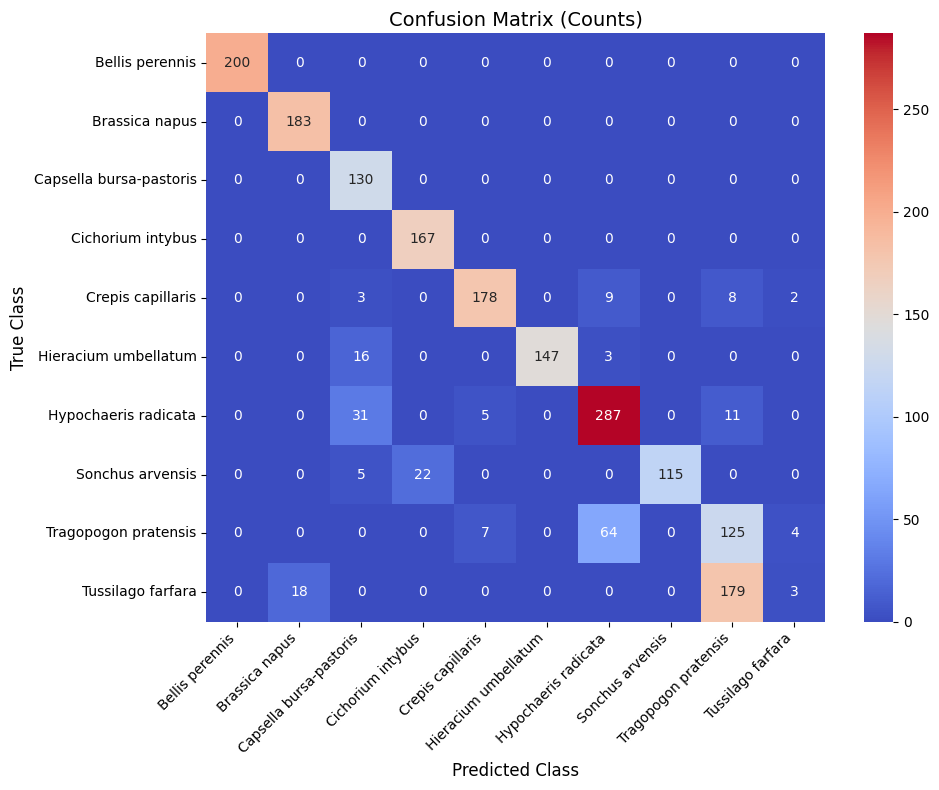

In [10]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/base_model_fill_val.pth", map_location=device)
model_base.load_state_dict(ckpt["model_state_dict"])
model_base.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model_base, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

## Base Model (Erik's) & Filling missing size & Validation split & Augmentation

In [7]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=True
    ,aug_bool=True
    ,norm_bool=False
    ,sep_val_bool=False
)
num_classes = len(classes)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (

In [29]:
val_counts = Counter([val_dataset[i][2].item() for i in range(len(val_dataset))])

print("Training set class distribution:")
for k in sorted(val_counts):
    print(k, idx_to_class[int(k)], val_counts[k])

Training set class distribution:
0 Bellis perennis 169
1 Brassica napus 181
2 Capsella bursa-pastoris 185
3 Cichorium intybus 193
4 Crepis capillaris 166
5 Hieracium umbellatum 153
6 Hypochaeris radicata 166
7 Sonchus arvensis 189
8 Tragopogon pratensis 167
9 Tussilago farfara 171


In [30]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model_base
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="base_model_fill_val_aug.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=20
    ,early_stopping_patience=8
)

100%|██████████| 218/218 [00:20<00:00, 10.40it/s]


Epoch 1/20 | Train Loss: 0.0233, Train Acc: 0.9920
| Val Loss: 0.0626, Val Acc: 0.9747
Val Recall per class: tensor([1.0000, 1.0000, 0.9784, 0.9534, 0.9940, 1.0000, 0.9819, 0.9524, 0.8922,
        1.0000])
Saved new best model (Val Acc = 0.9747)


100%|██████████| 218/218 [00:20<00:00, 10.43it/s]


Epoch 2/20 | Train Loss: 0.0078, Train Acc: 0.9971
| Val Loss: 0.2233, Val Acc: 0.9362


100%|██████████| 218/218 [00:20<00:00, 10.51it/s]


...

Epoch 18/20 | Train Loss: 0.0140, Train Acc: 0.9955
| Val Loss: 0.0190, Val Acc: 0.9937


100%|██████████| 218/218 [00:20<00:00, 10.50it/s]


Epoch 19/20 | Train Loss: 0.0084, Train Acc: 0.9974
| Val Loss: 0.0813, Val Acc: 0.9822


100%|██████████| 218/218 [00:20<00:00, 10.44it/s]


Epoch 20/20 | Train Loss: 0.0287, Train Acc: 0.9920
| Val Loss: 0.0937, Val Acc: 0.9730
Val Recall per class: tensor([1.0000, 0.9945, 0.9676, 0.8497, 0.9880, 1.0000, 0.9639, 0.9947, 0.9880,
        1.0000])
Reloaded best model from epoch 16 (Val Acc=0.9948)



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 7.424270153045654
Mean of batch means: 0.6598353053702682
Mean of batch stds: 0.785173879295099

Test Accuracy: 0.7768
Test Recall per class:
Class 0 (Bellis perennis): 0.0211
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9617
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0550
Class 5 (Hieracium umbellatum): 0.9200
Class 6 (Hypochaeris radicata): 0.9250
Class 7 (Sonchus arvensis): 0.8144
Class 8 (Tragopogon pratensis): 0.9940
Class 9 (Tussilago farfara): 1.0000


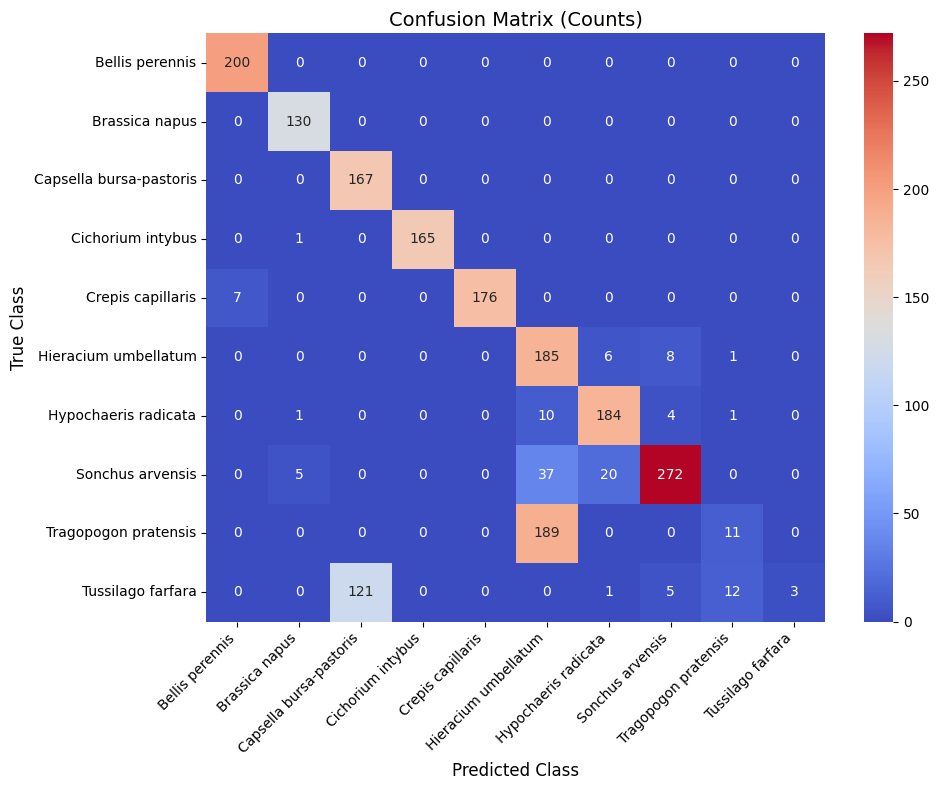

In [31]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/base_model_fill_val_aug.pth", map_location=device)
model_base.load_state_dict(ckpt["model_state_dict"])
model_base.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model_base, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

## Base Model to dense 256-dim & Filling missing size & Validation split & Augmentation

In [20]:
model_base256 = CNN256WithSizeMLP(num_classes=10).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_base256.parameters(), lr=0.001)

In [21]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model_base256
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="256base_model_fill_val.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=20
    ,early_stopping_patience=8
)

100%|██████████| 202/202 [00:18<00:00, 10.95it/s]


Epoch 1/20 | Train Loss: 0.3456, Train Acc: 0.8869
| Val Loss: 1.1626, Val Acc: 0.7234
Val Recall per class: tensor([0.9006, 0.9708, 0.7778, 0.7556, 0.0196, 0.9937, 0.4928, 0.1214, 0.9881,
        1.0000])
Saved new best model (Val Acc = 0.7234)


100%|██████████| 202/202 [00:18<00:00, 11.03it/s]


Epoch 2/20 | Train Loss: 0.1655, Train Acc: 0.9423
| Val Loss: 0.2238, Val Acc: 0.9208
Saved new best model (Val Acc = 0.9208)


100%|██████████| 202/202 [00:18<00:00, 10.97it/s]


...

Epoch 18/20 | Train Loss: 0.0440, Train Acc: 0.9851
| Val Loss: 0.1844, Val Acc: 0.9400


100%|██████████| 202/202 [00:18<00:00, 10.99it/s]


Epoch 19/20 | Train Loss: 0.0562, Train Acc: 0.9844
| Val Loss: 0.2961, Val Acc: 0.9127


100%|██████████| 202/202 [00:18<00:00, 11.00it/s]


Epoch 20/20 | Train Loss: 0.0425, Train Acc: 0.9855
| Val Loss: 0.1000, Val Acc: 0.9728
Val Recall per class: tensor([0.9834, 0.9883, 0.9869, 0.9611, 0.9673, 0.8562, 1.0000, 0.9929, 0.9940,
        1.0000])
Reloaded best model from epoch 17 (Val Acc=0.9907)



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 12.637947082519531
Mean of batch means: 0.8238828993234478
Mean of batch stds: 1.0451642626621684

Test Accuracy: 0.7347
Test Recall per class:
Class 0 (Bellis perennis): 0.1620
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9650
Class 6 (Hypochaeris radicata): 0.5100
Class 7 (Sonchus arvensis): 0.7754
Class 8 (Tragopogon pratensis): 0.9337
Class 9 (Tussilago farfara): 1.0000


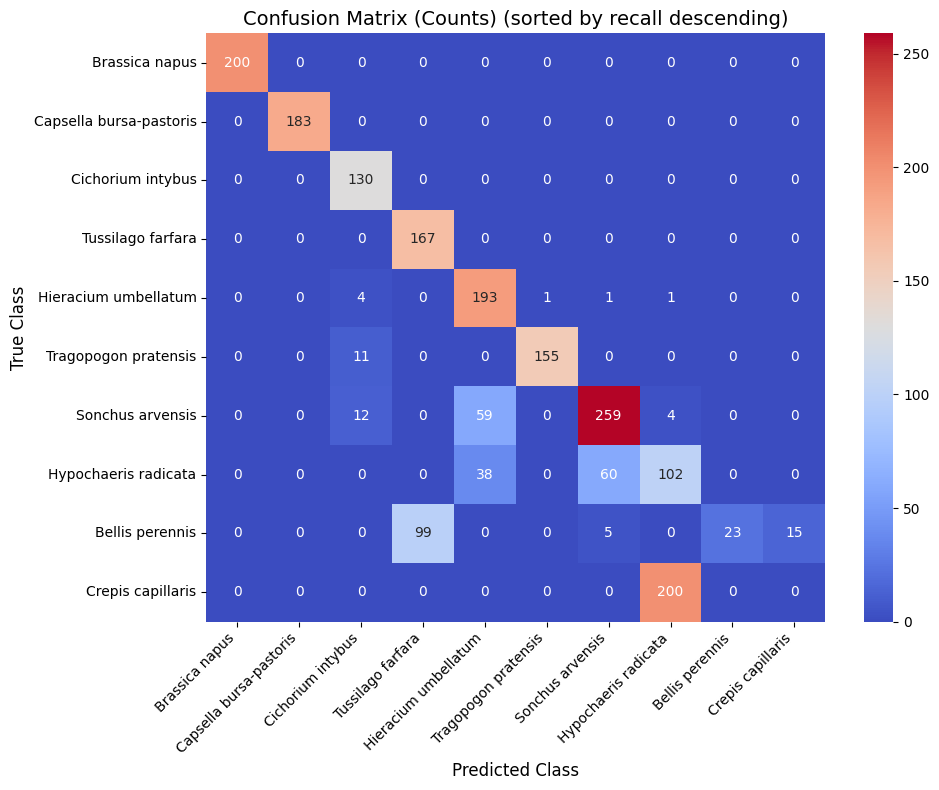

In [22]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/256base_model_fill_val.pth", map_location=device)
model_base.load_state_dict(ckpt["model_state_dict"])
model_base.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model_base256, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

# Focal loss

## Choosing optimal gamma

- gamma=0, alpha=None
- gamma=1, alpha=None
- gamma=2, alpha=None

Train on dataset with filled missing size measurements and validation dataset

In [4]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=True
    ,aug_bool=False
    ,norm_bool=False
    ,sep_val_bool=False
)
num_classes = len(classes)


Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 6462
Validation subset size: 1616
Train subset size: 6462
Validation subset size: 1616
Datase

In [ ]:
focal_model = CNNWithSizeMLP(num_classes=len(classes)).to(device)

loss_fn = FocalLoss(gamma=2.0)
optimizer = torch.optim.Adam(focal_model.parameters(), lr=0.001)